<a href="https://colab.research.google.com/github/Viresh-tarapur/AIML_and_data_science_projects/blob/main/downsampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
file = '/content/dog.png'
print("Reading the image...")
image = cv.imread(file, cv.IMREAD_GRAYSCALE)
if image is None:
    raise FileNotFoundError(f"Image file '{file}' not found!")

image_height, image_width = image.shape
print(f"Original Image Size: {image_width}x{image_height}")

np.show.file()


Reading the image...
Original Image Size: 128x128


In [ ]:
image_flat = image.flatten()


In [ ]:
dsimage_width = image_width // 2
dsimage_height = image_height // 2
downsampledimage = [0] * (dsimage_width * dsimage_height)


In [ ]:
print("Horizontal Convolution...")
image_h = image_flat.copy()
for x in range(image_height):
    for y in range(image_width):
        a = image_h[x*image_width + y-1] if y-1 >= 0 else 0
        b = 2 * image_h[x*image_width + y]
        c = image_h[x*image_width + y+1] if y+1 < image_width else 0
        new_pixel = (a + b + c) / 4
        image_h[x*image_width + y] = new_pixel

Horizontal Convolution...


/tmp/ipython-input-837480465.py:6: RuntimeWarning: overflow encountered in scalar multiply
  b = 2 * image_h[x*image_width + y]
/tmp/ipython-input-837480465.py:8: RuntimeWarning: overflow encountered in scalar add
  new_pixel = (a + b + c) / 4


In [ ]:
print("Vertical Convolution...")
image_v = image_h.copy()
for y in range(image_width):
    for x in range(image_height):
        a = image_v[(x-1)*image_width + y] if x-1 >= 0 else 0
        b = 2 * image_v[x*image_width + y]
        c = image_v[(x+1)*image_width + y] if x+1 < image_height else 0
        new_pixel = (a + b + c) / 4
        image_v[x*image_width + y] = new_pixel


Vertical Convolution...


In [ ]:
print("Downsampling...")
for x in range(dsimage_height):
    for y in range(dsimage_width):
        pixel_value = image_v[(2*x)*image_width + (2*y)]
        downsampledimage[x*dsimage_width + y] = pixel_value


Downsampling...


In [ ]:
print("Visualizing downsampled image...")
dsimage_algo = np.zeros((dsimage_height, dsimage_width))
for row in range(dsimage_height):
    for col in range(dsimage_width):
        dsimage_algo[row, col] = downsampledimage[row*dsimage_width + col]



Visualizing downsampled image...


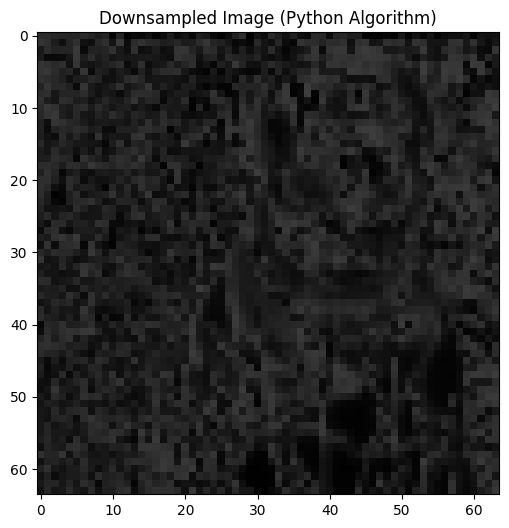

In [ ]:
plt.figure(figsize=(6,6))
plt.imshow(dsimage_algo, cmap='gray', vmin=0, vmax=255)
plt.title("Downsampled Image (Python Algorithm)")
plt.show()


In [ ]:
print("Generating Vivado RAM binary file...")
ram_index = 20
with open(file.split('.')[0] + '_ram.txt', 'w') as imgfile:
    for row in range(image_height):
        for col in range(image_width):
            pixel_val = int(image[row, col])
            imgfile.write(f"ram[{ram_index}] = 8'b{pixel_val:08b};\n")
            ram_index += 1

print(f"Binary RAM file saved as '{file.split('.')[0]}_ram.txt'")

Generating Vivado RAM binary file...
Binary RAM file saved as '/content/dog_ram.txt'
